# Versioned data access with Icechunk

**Summary**: Demonstrates how to read the IS2SMGPSIT-V1 dataset from its [Icechunk](https://icechunk.io) repository on S3, including how to pin an immutable release tag for reproducibility, inspect the version history, and make a few key figures directly from the store.

**Version history**: Version 1 (08/2026)

**Note on environments**: Icechunk requires Python >=3.12 and Zarr v3, so this notebook does *not* run in the standard book environment. Create the dedicated environment and kernel first (from the parent directory of `icesat2-book`):

```bash
uv venv --python 3.12 is2book_icechunk_env
source is2book_icechunk_env/bin/activate
cd icesat2-book
uv pip install -r requirements-icechunk.txt
python -m ipykernel install --user --name is2book_icechunk_env --display-name "Icechunk (py3.12)"
```

Then select the **Icechunk (py3.12)** kernel to run this notebook.


## Why Icechunk?

A plain Zarr store on S3 is a single mutable snapshot: when a new winter of data is added, anyone reading the store gets different numbers than before, and there is no record of what changed. Icechunk adds git-like version control on top of the Zarr data model:

- every update is a **commit** with a message and timestamp,
- releases are immutable **tags** (e.g. `v1.0` = the peer-reviewed record),
- the `main` branch always points at the latest complete record,
- chunks shared between versions are stored once, so appending a new season only stores the new data.

If you are reproducing published results, pin the tag cited in the paper. If you just want the latest data, read `main`.


In [1]:
### Import notebook dependencies

import icechunk as ic
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import warnings

warnings.filterwarnings('ignore')

print('icechunk:', ic.__version__, '| xarray:', xr.__version__)


icechunk: 2.0.6 | xarray: 2026.4.0


## Open the repository (anonymous read)

The repository lives on the same public S3 bucket as the plain Zarr store. No AWS credentials are needed for read access.


In [2]:
BUCKET = 'icesat-2-sea-ice-us-west-2'
PREFIX = 'is2smsitgp/v0.1/icechunk'
TAG = 'v0.1'  # immutable release tag to pin below

storage = ic.s3_storage(bucket=BUCKET, prefix=PREFIX, region='us-west-2', anonymous=True)
repo = ic.Repository.open(storage)

print('branches:', repo.list_branches())
print('tags:', repo.list_tags())


branches: {'main'}
tags: {'v0.1'}


## Inspect the version history

Each commit records what changed and when. As new winters are appended (one commit + one tag per release), this history becomes the provenance record for the dataset.


In [3]:
for snapshot in repo.ancestry(branch='main'):
    print(f'{snapshot.written_at:%Y-%m-%d %H:%M}  {snapshot.id}  {snapshot.message}')


2026-08-09 00:41  F5VZQ9D22KKJ4369WRS0  IS2SMGPSIT v0.1: import from plain Zarr (s3://icesat-2-sea-ice-us-west-2/is2smsitgp/dev_v7/zarr/GPSat_multivar_20181101-20250430.zarr)
2026-06-10 11:43  1CECHNKREP0F1RSTCMT0  Repository initialized


## Read the latest data (`main`)

Opening a session on `main` gives the most recent complete record as a regular `xarray.Dataset`, lazily loaded.


In [4]:
session_latest = repo.readonly_session(branch='main')
IS2_SMOS_SMAP = xr.open_zarr(session_latest.store, consolidated=False)

print(f"time range: {pd.Timestamp(IS2_SMOS_SMAP.time.values.min()):%Y-%m-%d} to "
      f"{pd.Timestamp(IS2_SMOS_SMAP.time.values.max()):%Y-%m-%d} "
      f"({IS2_SMOS_SMAP.sizes['time']} days)")
IS2_SMOS_SMAP


time range: 2018-11-01 to 2025-04-30 (1635 days)


<xarray.Dataset> Size: 10GB
Dimensions:                             (time: 1635, y: 448, x: 304)
Coordinates:
  * time                                (time) datetime64[ns] 13kB 2018-11-01...
  * y                                   (y) float32 2kB 5.838e+06 ... -5.338e+06
  * x                                   (x) float32 1kB -3.838e+06 ... 3.738e+06
Data variables: (12/20)
    crs                                 (time) int32 7kB dask.array<chunksize=(1,), meta=np.ndarray>
    ice_thickness_unc                   (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard                           (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    longitude                           (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    latitude                            (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_unc                       (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                                  ...
    mean_snow_depth_regions_1_5         (time) float32 7kB dask.array<chunksize=(1,), meta=np.ndarray>
    sea_ice_conc                        (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_unc                      (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_volume                      (time, y, x) float32 891MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    total_sea_ice_volume                (time) float32 7kB dask.array<chunksize=(1,), meta=np.ndarray>
    total_sea_ice_volume_regions_1_5    (time) float32 7kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/14)
    caa_uncertainty_caution:    Canadian Arctic Archipelago (CAA; NSIDC-0780 ...
    contact:                    Alek Petty (akpetty@umd.edu)
    description:                Monthly gridded Arctic sea ice thickness (fus...
    history:                    Created 2026-07-29
    inner_arctic_regions_note:  Inner-Arctic scalars (mean_*_regions_1_5, tot...
    n_timesteps:                1635
    ...                         ...
    time_coverage_start:        2018-11-01
    training_season_caution:    GP training is limited to a seasonal window (...
    product:                    IS2SMGPSIT
    product_version:            v0.1
    release_status:             pre-release (not peer reviewed)
    source_zarr:                s3://icesat-2-sea-ice-us-west-2/is2smsitgp/de...

## Pin an immutable release for reproducibility

Analyses supporting a publication should read from a tag, not `main`: the data at a tag never changes, even after new winters are appended. This is the version to cite.


In [5]:
session_release = repo.readonly_session(tag=TAG)
IS2_SMOS_SMAP_release = xr.open_zarr(session_release.store, consolidated=False)

print(f"tag {TAG!r}: {pd.Timestamp(IS2_SMOS_SMAP_release.time.values.min()):%Y-%m-%d} to "
      f"{pd.Timestamp(IS2_SMOS_SMAP_release.time.values.max()):%Y-%m-%d} "
      f"({IS2_SMOS_SMAP_release.sizes['time']} days)")


tag 'v0.1': 2018-11-01 to 2025-04-30 (1635 days)


## Map one month

Select one calendar month, average its daily fields, and map the result. Change `MAP_MONTH` to any available month in `YYYY-MM` format. Only that month's thickness chunks are read from the store.


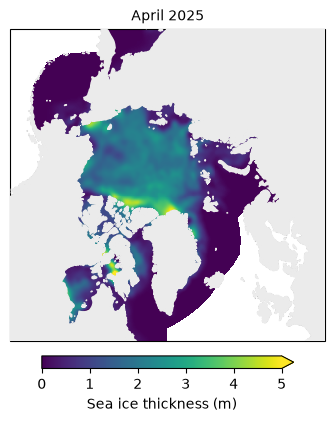

In [10]:
MAP_MONTH = '2025-04'

thickness_month = (
    IS2_SMOS_SMAP.ice_thickness
    .sel(time=MAP_MONTH)
    .mean('time', keep_attrs=True)
)

longitude = IS2_SMOS_SMAP.longitude
latitude = IS2_SMOS_SMAP.latitude
if 'time' in longitude.dims:
    longitude = longitude.isel(time=0, drop=True)
if 'time' in latitude.dims:
    latitude = latitude.isel(time=0, drop=True)

fig, ax = plt.subplots(
    figsize=(5, 5),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-45)},
)
im = ax.pcolormesh(
    longitude, latitude, thickness_month,
    transform=ccrs.PlateCarree(), cmap='viridis', vmin=0, vmax=5,
)
ax.add_feature(cfeature.LAND, color='0.92', zorder=5)
ax.coastlines(linewidth=0.3, zorder=3)
ax.set_extent([-179, 179, 54, 90], crs=ccrs.PlateCarree())
ax.set_title(pd.Timestamp(MAP_MONTH).strftime('%B %Y'), fontsize=10)
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.65, pad=0.04, extend='max')
cbar.set_label('Sea ice thickness (m)')
plt.show()


## Full daily time series

The store includes precomputed daily aggregates, so these plots need almost no data transfer: inner-Arctic-Ocean (NSIDC regions 1–5) mean thickness and pan-Arctic volume. Growth seasons only (May–August omitted) are shown with small markers so summer gaps do not connect across seasons.


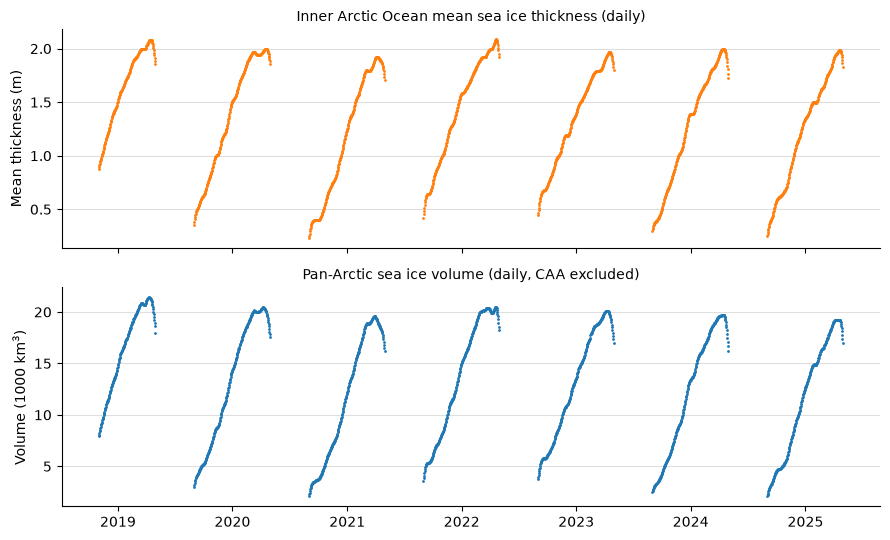

In [7]:
thickness_daily = IS2_SMOS_SMAP.mean_sea_ice_thickness_regions_1_5
volume_daily = IS2_SMOS_SMAP.total_sea_ice_volume / 1e3

# Reindex to a continuous daily axis and drop May–August so seasons do not connect
t0 = pd.Timestamp(thickness_daily.time.values.min())
t1 = pd.Timestamp(thickness_daily.time.values.max())
all_days = pd.date_range(t0, t1, freq='D')
thickness_plot = thickness_daily.reindex(time=all_days)
thickness_plot = thickness_plot.where(~thickness_plot.time.dt.month.isin([5, 6, 7, 8]))
volume_plot = volume_daily.reindex(time=all_days)
volume_plot = volume_plot.where(~volume_plot.time.dt.month.isin([5, 6, 7, 8]))

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

thickness_plot.plot(
    ax=ax0, color='C1', marker='.', markersize=2, linestyle='None',
)
ax0.set_ylabel('Mean thickness (m)')
ax0.set_title('Inner Arctic Ocean mean sea ice thickness (daily)', fontsize=10)
ax0.set_xlabel('')

volume_plot.plot(
    ax=ax1, color='C0', marker='.', markersize=2, linestyle='None',
)
ax1.set_ylabel('Volume (1000 km$^3$)')
ax1.set_title('Pan-Arctic sea ice volume (daily, CAA excluded)', fontsize=10)
ax1.set_xlabel('')

for ax in (ax0, ax1):
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## Seven-winter thickness maps

Resample the daily thickness fields to calendar-month means, average November–April for each growth season, and use the same `staticArcticMaps_equal_panels` layout as notebook `11e`. This reads the gridded thickness record, so it is the most data-intensive example in the notebook.


In [8]:
from utils.plotting_utils import (
    staticArcticMaps_equal_panels,
    compute_gridcell_winter_means,
)

# Monthly means on month-start timestamps, matching notebook 11e.
thickness_monthly = (
    IS2_SMOS_SMAP.ice_thickness
    .resample(time='1MS')
    .mean(keep_attrs=True)
)

years = list(range(2018, 2025))
thickness_winter_means = compute_gridcell_winter_means(
    thickness_monthly, years=years,
)

# Fill missing open-water cells with zero, but keep land masked.
region_mask = IS2_SMOS_SMAP.region_mask
if 'time' in region_mask.dims:
    region_mask = region_mask.isel(time=0, drop=True)
ocean = region_mask.isin(list(range(1, 19))).compute()
thickness_winter_means = thickness_winter_means.fillna(0).where(ocean)

print('winters:', list(thickness_winter_means.time.values))


winters: [np.str_('Nov 2018 - Apr 2019'), np.str_('Nov 2019 - Apr 2020'), np.str_('Nov 2020 - Apr 2021'), np.str_('Nov 2021 - Apr 2022'), np.str_('Nov 2022 - Apr 2023'), np.str_('Nov 2023 - Apr 2024'), np.str_('Nov 2024 - Apr 2025')]


findfont: Failed to find font weight medium, now using 400.


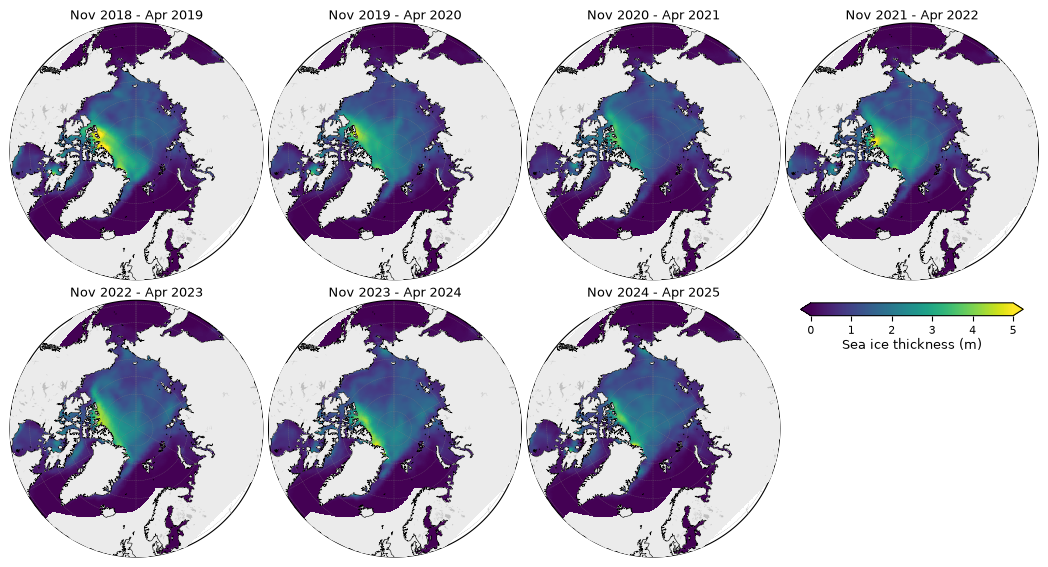

In [9]:
fig = staticArcticMaps_equal_panels(
    thickness_winter_means,
    dates=thickness_winter_means.time.values,
    title='',
    set_cbarlabel='Sea ice thickness (m)',
    cmap='viridis',
    vmin=0,
    vmax=5,
    ocean_mask=ocean.values,
    savefig=False,
)
fig


## Notes

- Anonymous (unauthenticated) reads work for all public prefixes; only dataset publishing requires AWS credentials.
- New winters are appended to `main` with `scripts/icechunk_append_season.py` (one commit + one new tag per release); previously tagged releases are never modified.
- The single-month map reads only one month of daily gridded thickness; the full time series use compact precomputed aggregates. The seven-winter map reads the complete gridded thickness record.
- The plain (non-versioned) Zarr snapshot of each release remains available alongside the Icechunk repository for tools that cannot read Icechunk — see the data access notes in notebook `11a`.
